In [15]:
import numpy as np
import random as rd
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png"

### 10-armed Testbed

In [16]:
rng = np.random.default_rng()

In [17]:
NtestsAB = 2000
kAB = 10
qvaluesAB = rng.standard_normal((NtestsAB, kAB))
qvaluesNSAB = np.ones((NtestsAB, kAB)) * qvaluesAB[0, :]

### Action-value Methods

In [18]:
def sampleAverage(maxIter, epsilon=0, NS=False, alpha=0, qInit=0, beta=False, UCB=0):
    Q = qInit * np.ones((NtestsAB, kAB))
    N = np.zeros((NtestsAB, kAB), dtype=int)
    AvgReward = np.zeros(maxIter)
    AvgOptimal = np.zeros(maxIter)
    nExplore = np.zeros(maxIter)
    qvaluesCurr = qvaluesNSAB if NS else qvaluesAB
    qstarsCurr = np.max(qvaluesCurr, axis=1)
    if beta:
        oHat = 1 - (1-alpha)**np.arange(maxIter+1)

    for t in range(maxIter):
        if UCB:
            offset = UCB * np.sqrt(np.log(t+1)/N)
            offset[N == 0] = np.inf
        At = np.argmax(Q + (0 if not UCB else offset), axis=1)
        explore = rng.random(NtestsAB) <= epsilon
        nExplore[t] = explore.sum()
        randomAt = rng.integers(kAB-1, size=NtestsAB)
        randomAt += randomAt >= At
        At[explore] = randomAt[explore]
        qvaluesAt = qvaluesCurr[np.arange(NtestsAB), At]
        AvgOptimal[t] = np.mean(qvaluesCurr[np.arange(NtestsAB), At] == qstarsCurr)
        rewards = rng.normal(loc=qvaluesAt, scale=1)
        AvgReward[t] = np.mean(rewards)
        N[np.arange(NtestsAB),At] += 1
        increment = 1 / N[np.arange(NtestsAB), At]
        if alpha:
            increment = alpha
            if beta:
                increment = alpha / oHat[N[np.arange(NtestsAB), At]]
        Q[np.arange(NtestsAB),At] = Q[np.arange(NtestsAB), At] + increment * (rewards - Q[np.arange(NtestsAB), At])
        if NS:
            qvaluesCurr += rng.normal(loc=np.zeros((NtestsAB, kAB)), scale=0.01)
            qstarsCurr = np.max(qvaluesCurr, axis=1)

    return Q, AvgReward, AvgOptimal, nExplore
            

In [19]:
def gradientBandit(maxIter, baseline=True, NS=False, alpha=0.1):
    H = np.zeros((NtestsAB, kAB))
    R = np.zeros(NtestsAB)
    AvgReward = np.zeros(maxIter)
    AvgOptimal = np.zeros(maxIter)
    qvaluesCurr = qvaluesNSAB if NS else qvaluesGB
    qstarsCurr = np.max(qvaluesCurr, axis=1)

    for t in range(maxIter):
        pi = np.exp(H)
        pi /= pi.sum(axis=1, keepdims=True)
        u = rng.random(NtestsAB)
        At = (np.cumsum(pi, axis=1) < u[:, None]).sum(axis=1)
        qvaluesAt = qvaluesCurr[np.arange(NtestsAB), At]
        AvgOptimal[t] = np.mean(qvaluesCurr[np.arange(NtestsAB), At] == qstarsCurr)
        rewards = rng.normal(loc=qvaluesAt, scale=1)
        AvgReward[t] = np.mean(rewards)
        bl = np.zeros(NtestsAB) if not baseline else (rewards if t == 0 else R / t)
        H[np.arange(NtestsAB), At] = H[np.arange(NtestsAB), At] + alpha * (rewards - bl) * (1 - pi[np.arange(NtestsAB), At])
        H[np.arange(kAB) != At[:, None]] -= (alpha * (rewards[:, None] - bl[:, None]) * pi)[np.arange(kAB) != At[:, None]]
        R += rewards
        if NS:
            qvaluesCurr += rng.normal(loc=np.zeros((NtestsAB, kAB)), scale=0.01)
            qstarsCurr = np.max(qvaluesCurr, axis=1)

    return H, AvgReward, AvgOptimal


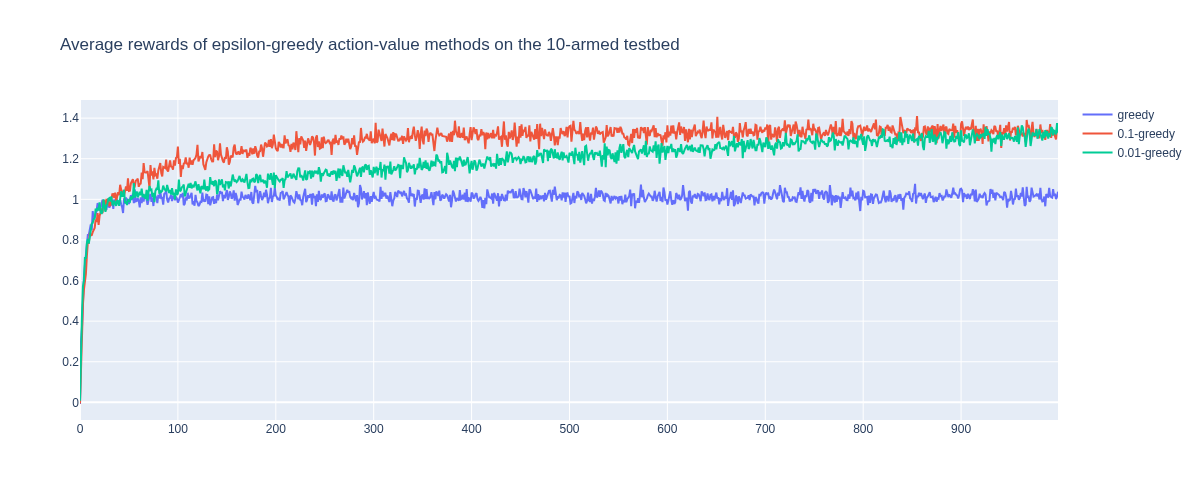

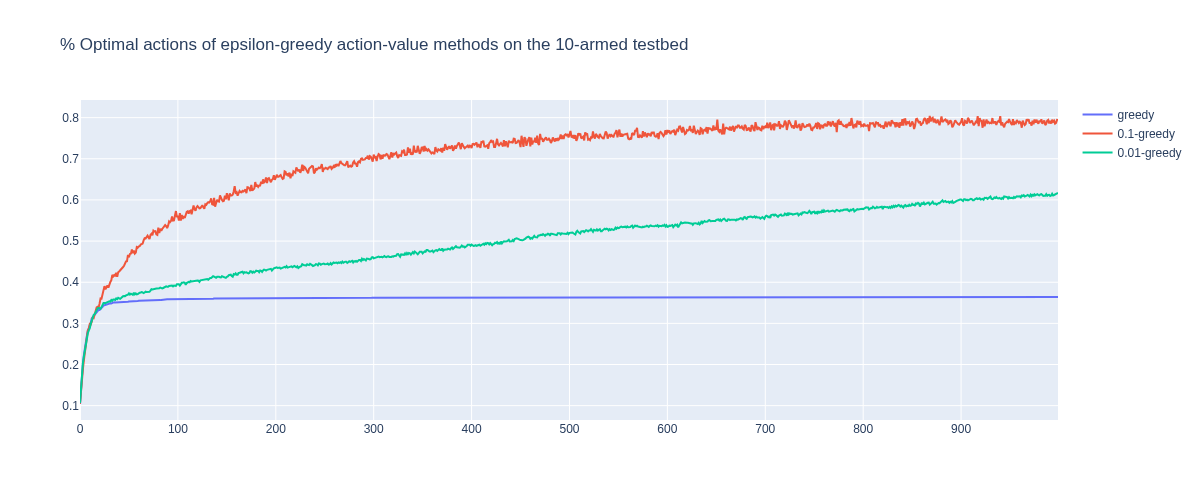

In [20]:
nSampleAB = 1000
Qsample, AvgRSample, AvgOptSample, nExploreSample = sampleAverage(nSampleAB)
Qsample01, AvgRSample01, AvgOptSample01, nExploreSample01 = sampleAverage(nSampleAB, epsilon=0.1)
Qsample001, AvgRSample001, AvgOptSample001, nExploreSample001 = sampleAverage(nSampleAB, epsilon=0.01)
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRSample, name="greedy"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRSample01, name="0.1-greedy"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRSample001, name="0.01-greedy"))
fig.update_layout(width=1200, title="Average rewards of epsilon-greedy action-value methods on the 10-armed testbed")
fig.show()
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptSample, name="greedy"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptSample01, name="0.1-greedy"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptSample001, name="0.01-greedy"))
fig.update_layout(width=1200, title="% Optimal actions of epsilon-greedy action-value methods on the 10-armed testbed")
fig.show()

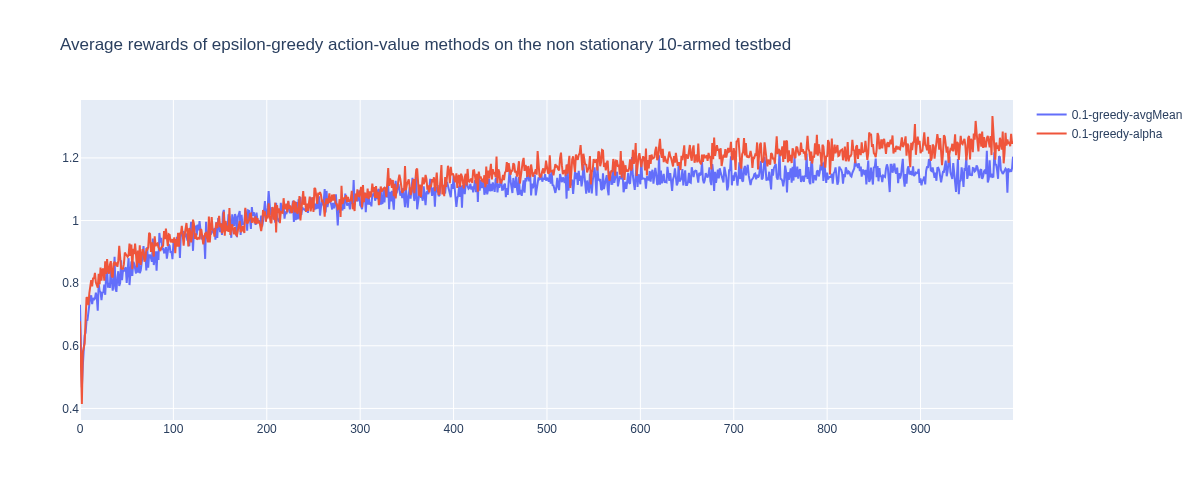

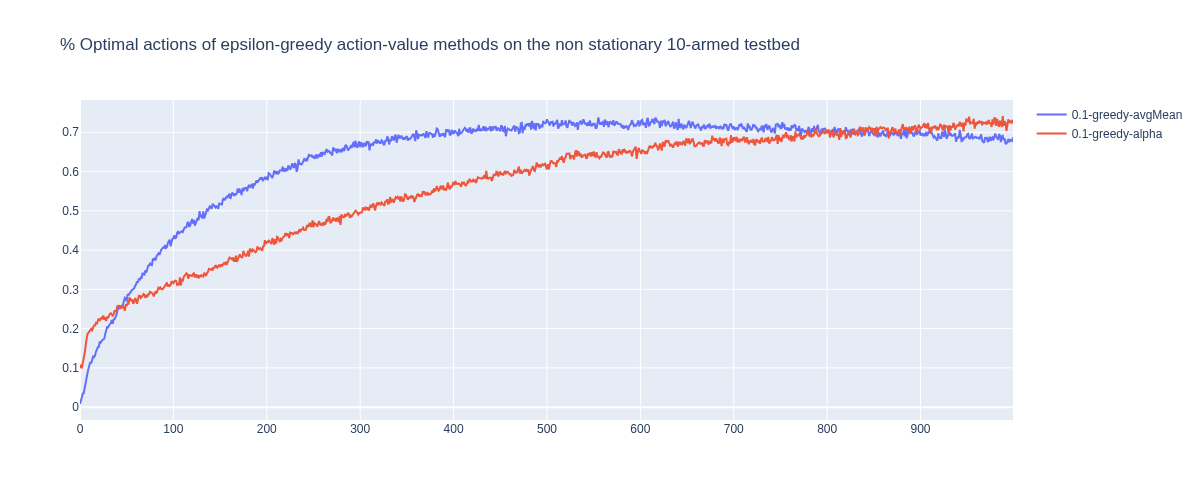

In [21]:
nSampleAB = 1000
Qsample01NS, AvgRSample01NS, AvgOptSample01NS, nExploreSample01NS = sampleAverage(nSampleAB, epsilon=0.1, NS=True)
Qalpha01NS, AvgRalpha01NS, AvgOptalpha01NS, nExploreSample01NS = sampleAverage(nSampleAB, epsilon=0.1, NS=True, alpha=0.1)
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRSample01NS, name="0.1-greedy-avgMean"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalpha01NS, name="0.1-greedy-alpha"))
fig.update_layout(width=1200, title="Average rewards of epsilon-greedy action-value methods on the non stationary 10-armed testbed")
fig.show()
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptSample01NS, name="0.1-greedy-avgMean"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalpha01NS, name="0.1-greedy-alpha"))
fig.update_layout(width=1200, title="% Optimal actions of epsilon-greedy action-value methods on the non stationary 10-armed testbed")
fig.show()

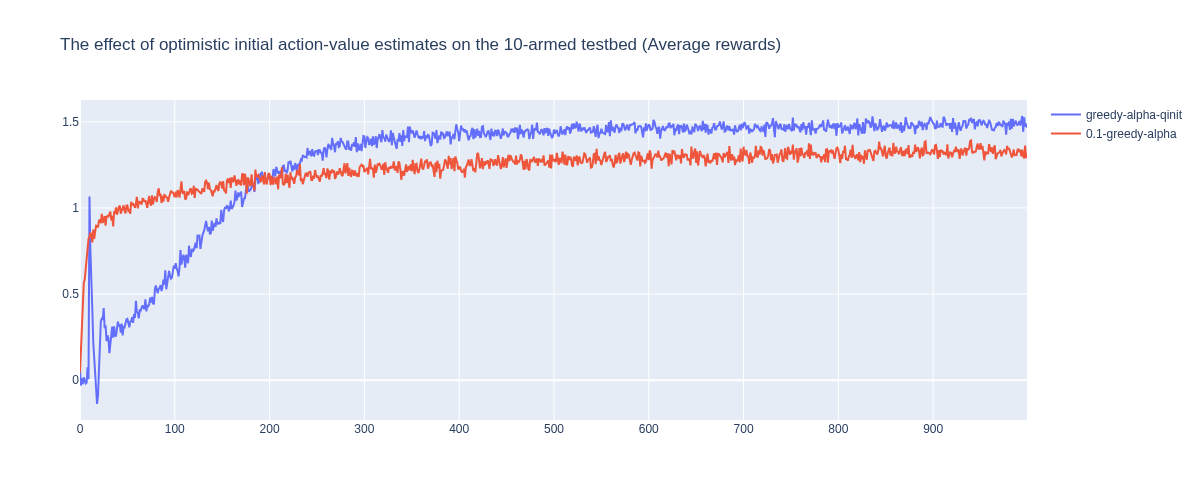

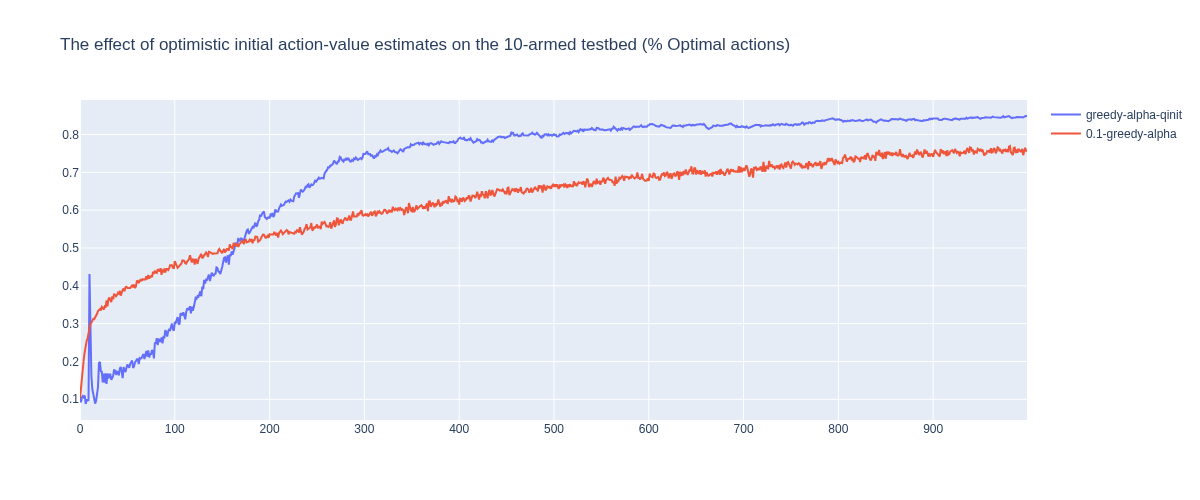

In [22]:
nSampleAB = 1000
Qalphaqinit, AvgRalphaqinit, AvgOptalphaqinit, nExploreSampleqinit = sampleAverage(nSampleAB, alpha=0.1, qInit=5)
Qalpha01, AvgRalpha01, AvgOptalpha01, nExplorealpha01 = sampleAverage(nSampleAB, epsilon=0.1, alpha=0.1)

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalphaqinit, name="greedy-alpha-qinit"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalpha01, name="0.1-greedy-alpha"))
fig.update_layout(width=1200, title="The effect of optimistic initial action-value estimates on the 10-armed testbed (Average rewards)")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalphaqinit, name="greedy-alpha-qinit"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalpha01, name="0.1-greedy-alpha"))
fig.update_layout(width=1200, title="The effect of optimistic initial action-value estimates on the 10-armed testbed (% Optimal actions)")
fig.show()


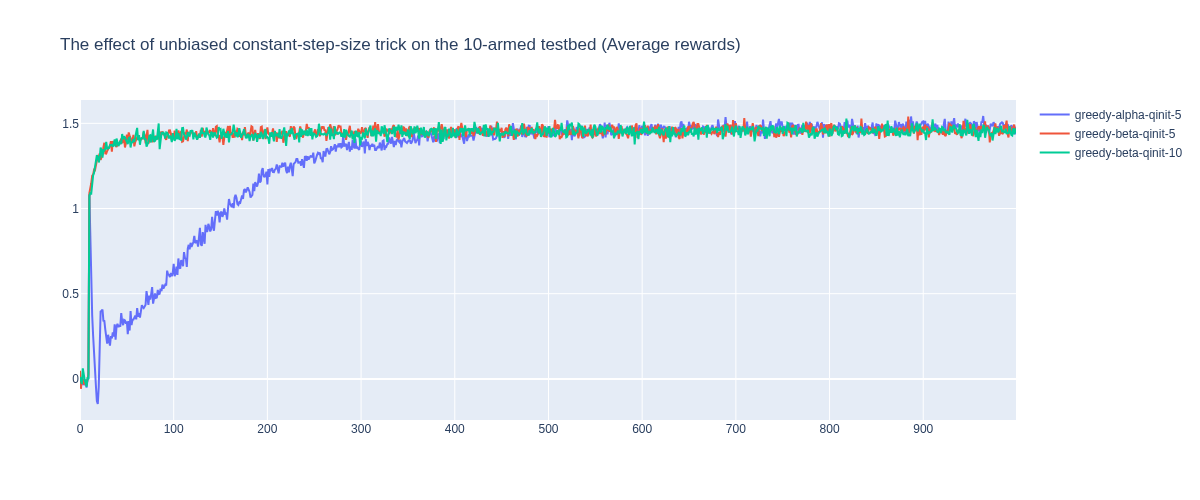

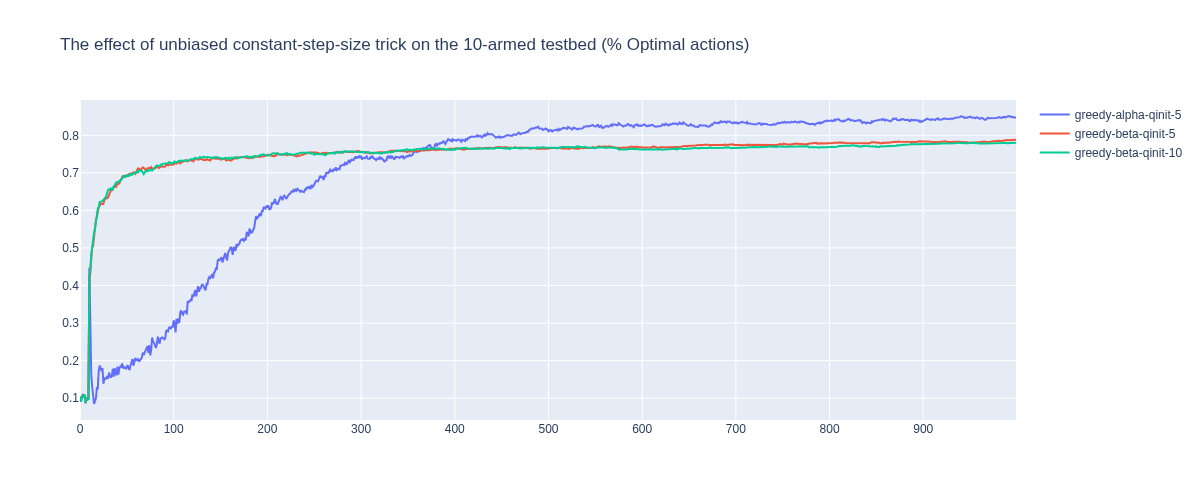

In [23]:
nSampleAB = 1000
Qalphaqinit, AvgRalphaqinit, AvgOptalphaqinit, nExploreSampleqinit = sampleAverage(nSampleAB, alpha=0.1, qInit=5)
QalphaqinitO5, AvgRalphaqinitO5, AvgOptalphaqinitO5, nExploreSampleqinitO5 = sampleAverage(nSampleAB, alpha=0.1, qInit=5, beta=True)
QalphaqinitO10, AvgRalphaqinitO10, AvgOptalphaqinitO10, nExploreSampleqinitO10 = sampleAverage(nSampleAB, alpha=0.1, qInit=10, beta=True)

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalphaqinit, name="greedy-alpha-qinit-5"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalphaqinitO5, name="greedy-beta-qinit-5"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalphaqinitO10, name="greedy-beta-qinit-10"))
fig.update_layout(width=1200, title="The effect of unbiased constant-step-size trick on the 10-armed testbed (Average rewards)")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalphaqinit, name="greedy-alpha-qinit-5"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalphaqinitO5, name="greedy-beta-qinit-5"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalphaqinitO10, name="greedy-beta-qinit-10"))
fig.update_layout(width=1200, title="The effect of unbiased constant-step-size trick on the 10-armed testbed (% Optimal actions)")
fig.show()

/tmp/ipykernel_4187982/409386165.py:14: RuntimeWarning: invalid value encountered in divide
  offset = UCB * np.sqrt(np.log(t+1)/N)
/tmp/ipykernel_4187982/409386165.py:14: RuntimeWarning: divide by zero encountered in divide
  offset = UCB * np.sqrt(np.log(t+1)/N)


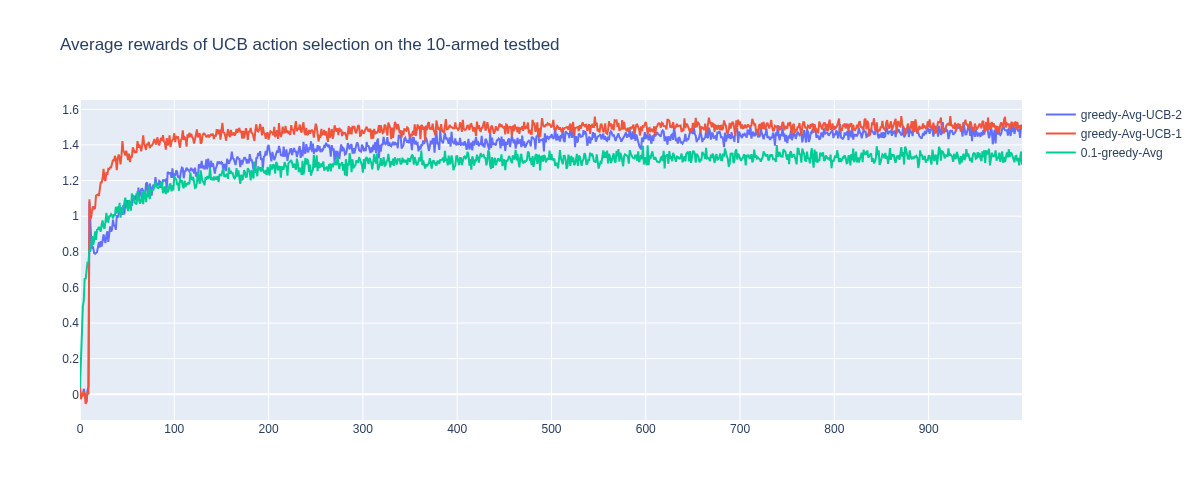

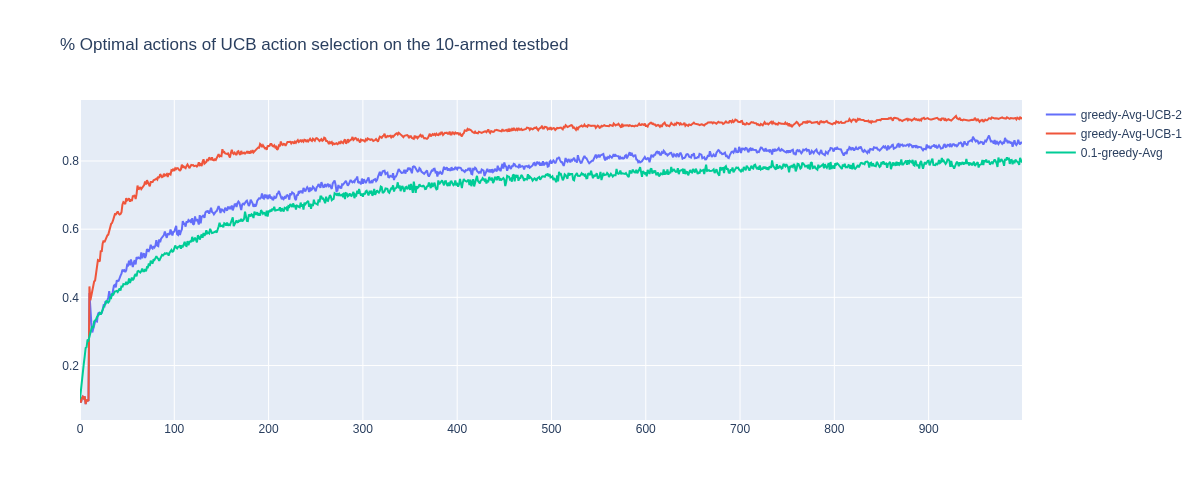

In [24]:
nSampleAB = 1000
QalphaUCB2, AvgRalphaUCB2, AvgOptalphaUCB2, nExploreSampleUCB2 = sampleAverage(nSampleAB, UCB=2)
QalphaUCB1, AvgRalphaUCB1, AvgOptalphaUCB1, nExploreSampleUCB1 = sampleAverage(nSampleAB, UCB=1)
Qalpha01, AvgRalpha01, AvgOptalpha01, nExplorealpha01 = sampleAverage(nSampleAB, epsilon=0.1)

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalphaUCB2, name="greedy-Avg-UCB-2"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalphaUCB1, name="greedy-Avg-UCB-1"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRalpha01, name="0.1-greedy-Avg"))
fig.update_layout(width=1200, title="Average rewards of UCB action selection on the 10-armed testbed")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalphaUCB2, name="greedy-Avg-UCB-2"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalphaUCB1, name="greedy-Avg-UCB-1"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptalpha01, name="0.1-greedy-Avg"))
fig.update_layout(width=1200, title="% Optimal actions of UCB action selection on the 10-armed testbed")
fig.show()

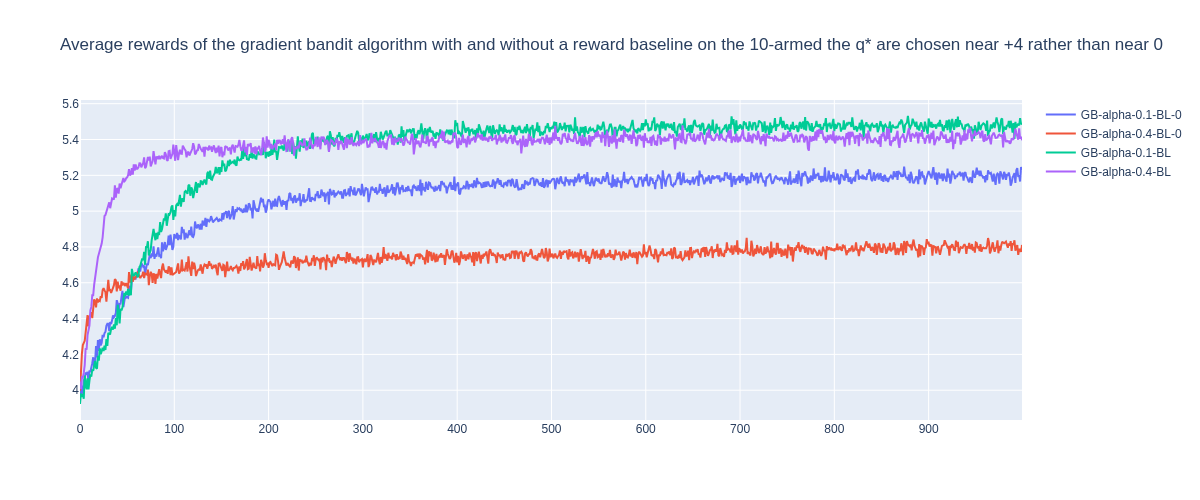

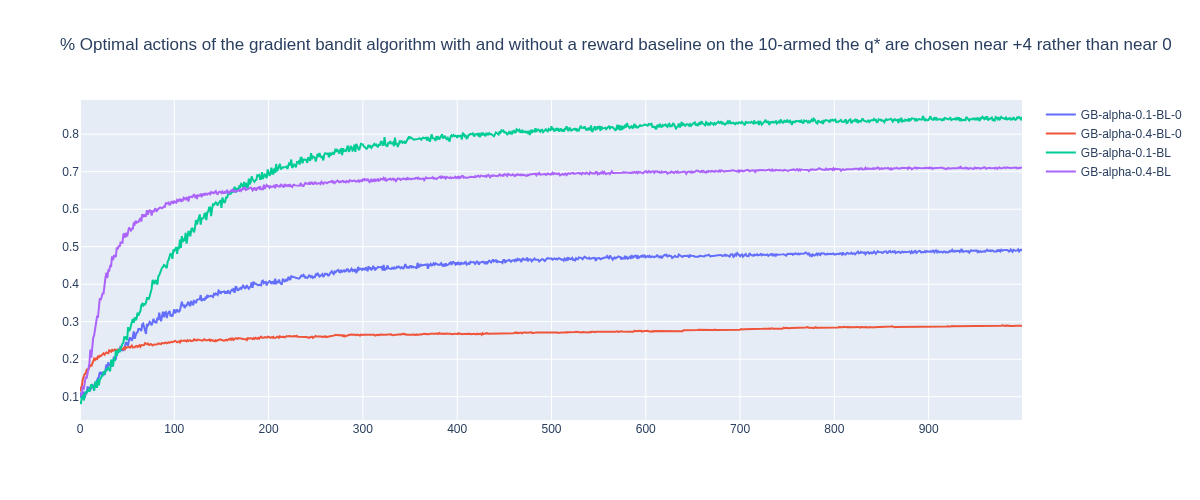

In [25]:
qvaluesGB = rng.normal(loc=4, scale=1, size=((NtestsAB, kAB)))
nSampleAB = 1000
HGBalpha01bl0, AvgRGBalpha01bl0, AvgOptGBalpha01bl0 = gradientBandit(nSampleAB, baseline=False, alpha=0.1)
HGBalpha04bl0, AvgRGBalpha04bl0, AvgOptGBalpha04bl0 = gradientBandit(nSampleAB, baseline=False, alpha=0.4)
HGBalpha01bl, AvgRGBalpha01bl, AvgOptGBalpha01bl = gradientBandit(nSampleAB, baseline=True, alpha=0.1)
HGBalpha04bl, AvgRGBalpha04bl, AvgOptGBalpha04bl = gradientBandit(nSampleAB, baseline=True, alpha=0.4)

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRGBalpha01bl0, name="GB-alpha-0.1-BL-0"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRGBalpha04bl0, name="GB-alpha-0.4-BL-0"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRGBalpha01bl, name="GB-alpha-0.1-BL"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgRGBalpha04bl, name="GB-alpha-0.4-BL"))
fig.update_layout(width=1200, title="Average rewards of the gradient bandit algorithm with and without a reward baseline on the 10-armed the q* are chosen near +4 rather than near 0")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptGBalpha01bl0, name="GB-alpha-0.1-BL-0"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptGBalpha04bl0, name="GB-alpha-0.4-BL-0"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptGBalpha01bl, name="GB-alpha-0.1-BL"))
fig.add_trace(go.Scatter(x=np.arange(nSampleAB), y=AvgOptGBalpha04bl, name="GB-alpha-0.4-BL"))
fig.update_layout(width=1200, title="% Optimal actions of the gradient bandit algorithm with and without a reward baseline on the 10-armed the q* are chosen near +4 rather than near 0")
fig.show()

### Parameter study

In [26]:
nSampleAB = 1000
# Epsilon greedy
epsilons = 0.4 * (2.0 ** np.arange(-7, 0))
epsilonGreedy = [sampleAverage(nSampleAB, epsilon=epsilon) for epsilon in epsilons]

# Gradient Bandit
qvaluesGB = rng.normal(loc=0, scale=1, size=((NtestsAB, kAB)))
alphasGB = 0.8 * (2.0 ** np.arange(-5, 3))
GB = [gradientBandit(nSampleAB, baseline=True, alpha=alpha) for alpha in alphasGB]

# UCB
UCBcs = 0.5 * (2.0 ** np.arange(-4, 4))
UCBs = [sampleAverage(nSampleAB, UCB=c) for c in UCBcs]

# Greedy optimistic
qInits = 0.5 * (2.0 ** np.arange(-2, 4))
optimisticGreedy = [sampleAverage(nSampleAB, alpha=0.1, qInit=qInit) for qInit in qInits]

/tmp/ipykernel_4187982/409386165.py:14: RuntimeWarning: invalid value encountered in divide
  offset = UCB * np.sqrt(np.log(t+1)/N)
/tmp/ipykernel_4187982/409386165.py:14: RuntimeWarning: divide by zero encountered in divide
  offset = UCB * np.sqrt(np.log(t+1)/N)


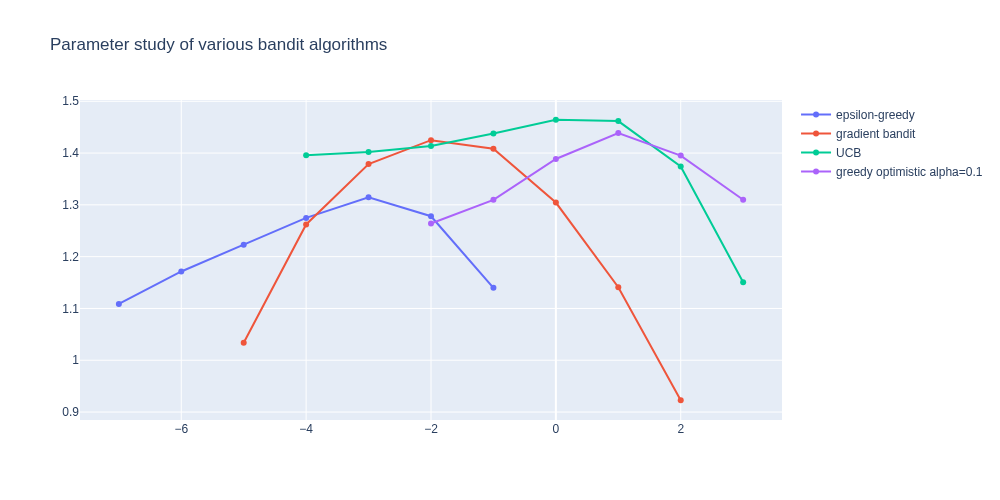

In [28]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.log2(epsilons/0.4), y=[epsilonGreedy[i][1].mean() for i in range(len(epsilons))], name="epsilon-greedy"))
fig.add_trace(go.Scatter(x=np.log2(alphasGB/0.8), y=[GB[i][1].mean() for i in range(len(alphasGB))], name="gradient bandit"))
fig.add_trace(go.Scatter(x=np.log2(UCBcs/0.5), y=[UCBs[i][1].mean() for i in range(len(UCBcs))], name="UCB"))
fig.add_trace(go.Scatter(x=np.log2(qInits/0.5), y=[optimisticGreedy[i][1].mean() for i in range(len(qInits))], name="greedy optimistic alpha=0.1"))
fig.update_layout(width=1000, title="Parameter study of various bandit algorithms")
fig.show()

In [30]:
nSampleNSAB = 200000
# Epsilon greedy
epsilons = 0.4 * (2.0 ** np.arange(-7, 0))
epsilonGreedy = [sampleAverage(nSampleNSAB, epsilon=epsilon, NS=True) for epsilon in epsilons]

In [31]:
# Epsilon greedy constant alpha
epsilonGreedyAlpha = [sampleAverage(nSampleNSAB, epsilon=epsilon, NS=True, alpha=0.1) for epsilon in epsilons]

In [32]:
# Gradient Bandit
qvaluesGB = rng.normal(loc=0, scale=1, size=((NtestsAB, kAB)))
alphasGB = 0.8 * (2.0 ** np.arange(-5, 3))
GB = [gradientBandit(nSampleNSAB, baseline=True, NS=True, alpha=alpha) for alpha in alphasGB]

In [33]:
# UCB
UCBcs = 0.5 * (2.0 ** np.arange(-4, 4))
UCBs = [sampleAverage(nSampleNSAB, NS=True, UCB=c) for c in UCBcs]

/tmp/ipykernel_4187982/409386165.py:14: RuntimeWarning: invalid value encountered in divide
  offset = UCB * np.sqrt(np.log(t+1)/N)
/tmp/ipykernel_4187982/409386165.py:14: RuntimeWarning: divide by zero encountered in divide
  offset = UCB * np.sqrt(np.log(t+1)/N)


In [34]:
# Greedy optimistic
qInits = 0.5 * (2.0 ** np.arange(-2, 4))
optimisticGreedy = [sampleAverage(nSampleNSAB, NS=True, alpha=0.1, qInit=qInit) for qInit in qInits]

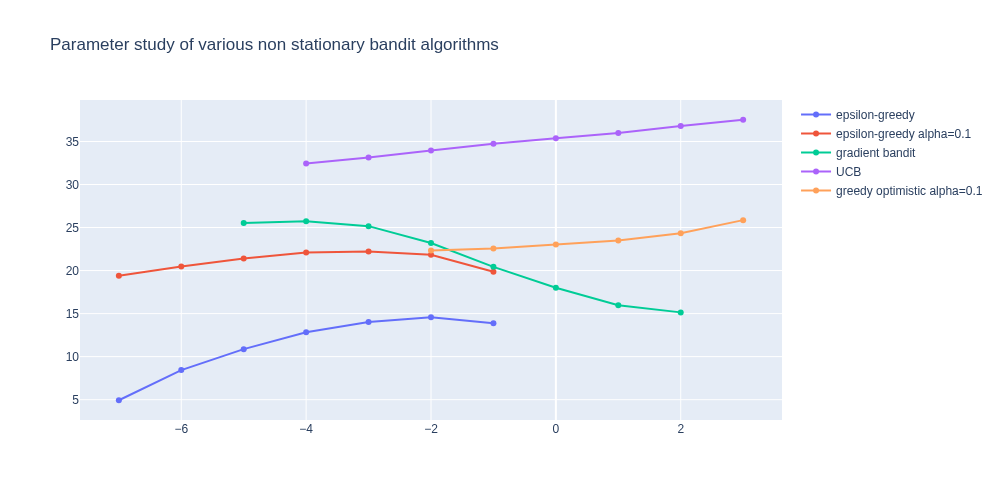

In [35]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.log2(epsilons/0.4), y=[epsilonGreedy[i][1][100000:].mean() for i in range(len(epsilons))], name="epsilon-greedy"))
fig.add_trace(go.Scatter(x=np.log2(epsilons/0.4), y=[epsilonGreedyAlpha[i][1][100000:].mean() for i in range(len(epsilons))], name="epsilon-greedy alpha=0.1"))
fig.add_trace(go.Scatter(x=np.log2(alphasGB/0.8), y=[GB[i][1][100000:].mean() for i in range(len(alphasGB))], name="gradient bandit"))
fig.add_trace(go.Scatter(x=np.log2(UCBcs/0.5), y=[UCBs[i][1][100000:].mean() for i in range(len(UCBcs))], name="UCB"))
fig.add_trace(go.Scatter(x=np.log2(qInits/0.5), y=[optimisticGreedy[i][1][100000:].mean() for i in range(len(qInits))], name="greedy optimistic alpha=0.1"))
fig.update_layout(width=1000, title="Parameter study of various non stationary bandit algorithms")
fig.show()